# AI Medical Symptom Routing System
**NTI Machine Learning Training - Final Project**

## Project Overview
This notebook contains the complete end-to-end pipeline for an AI-driven healthcare recommendation system. The system utilizes machine learning to predict potential medical conditions based on patient data and subsequently routes the patient to the most appropriate medical specialist.

## Team Members
* **Abdulrahman Jamal:** Data Engineering & EDA
* **Marwan Ayman:** Machine Learning Modeling
* **Hassan Raafat:** Deployment & Integration
* **Abdelbaset Haitham:** QA, Verification & Presentation

In [3]:
# Import all required libraries for the pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

---
# Phase 1: Data Engineering & EDA
**Responsible:** Abdulrahman Jamal

In this phase, we will load the raw dataset, clean it, engineer new features, and perform Exploratory Data Analysis (EDA) one step at a time.

## 1. Load Data

In [4]:
df = pd.read_csv('Data Warehouse Multiclass.csv')
print(f"Initial Shape: {df.shape}")
display(df.head())

Initial Shape: (280985, 39)


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


In [5]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  str    
 1   age_level             280985 non-null  str    
 2   gender                280985 non-null  str    
 3   bmi_level             280985 non-null  str    
 4   smoking               280985 non-null  str    
 5   diabetes              280985 non-null  str    
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cholesterol           280985 non-null  float64
 14  sleep_hours           280985 non-null  float64
 15  triglycerid

None

In [6]:
display(df.describe())

,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl
count,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000,280985.000000
mean,49.665865,0.547883,27.490663,0.128218,0.073390,5.947475,135.258646,224.045525,6.954652,178.995744,149.887200,7.489127,12.465326,134.405105,89.476720,15.003336,8.480577,74.497343,64.609147,129.725919
std,21.682350,0.249222,7.040373,0.187346,0.138243,0.954072,38.477865,35.525530,1.426412,67.336085,4.148644,1.013898,0.983375,20.542140,13.667219,6.830255,2.960646,11.402996,15.938525,27.352521
min,2.000000,0.000000,10.010000,0.000000,0.000000,3.500000,70.000000,150.000000,4.000000,50.000000,120.000000,0.003647,5.000236,90.000000,60.000000,0.000000,2.000000,50.000000,30.000000,70.000000
25%,32.000000,0.344827,22.100000,0.000000,0.000000,5.384805,100.000000,202.000000,6.200000,129.000000,148.946429,7.294863,12.287763,126.000000,84.000000,12.000000,7.200000,70.000000,58.000000,118.000000
50%,50.000000,0.551724,27.320000,0.071429,0.007299,5.800000,138.000000,225.000000,6.975185,179.000000,149.713320,7.458483,12.488407,134.167413,89.504587,14.982818,8.477600,74.487247,64.650655,129.983051
75%,67.000000,0.747126,32.700000,0.217063,0.115053,6.865766,160.000000,243.000000,7.700000,242.000000,150.720942,7.758562,12.686175,143.000000,95.000000,17.900000,9.800000,79.000000,72.000000,141.000000
max,89.000000,1.000000,95.690000,1.000000,1.000000,9.000000,300.000000,300.000000,10.000000,400.000000,180.000000,14.997087,19.999037,179.000000,119.000000,30.000000,15.000000,99.000000,99.000000,189.000000


In [7]:
display(df.describe(include='O'))

,composite_key,age_level,gender,bmi_level,smoking,diabetes,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,high_blood_pressure,sugar_consumption,education_level,employment_status,source_dataset,disease_flags,sublabel,label
count,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985,280985
unique,192,4,2,4,3,2,3,2,3,2,2,2,3,3,3,3,8,8,2
top,Middle_Female_Overweight_Never_No,Mature,Female,Obese,Never,No,High,No,High,No,Yes,Yes,Low,Tertiary,Unemployed,hypertension,"0,0,0",N,Abnormal
freq,6097,87632,148763,98377,127764,180351,120019,157182,101298,225935,146442,142168,123242,105285,95884,174982,106884,106884,174101


**Observation:** 
The raw dataset is loaded successfully. However, a preliminary data audit revealed severe **Data Leakage** issues. Several columns are directly derived from the target variables, which would allow the ML model to "cheat" during training.

## 2. Data Cleaning & Sanitization
In this step, we will:
1. Check and remove duplicate rows to prevent the model from overfitting.
2. Fix logical anomalies in numerical fields (e.g., converting negative billing values to absolute positive amounts).
3. Resolve Data Leakage & Clean the Data.
Based on the data audit, we must drop columns that leak target information.

In [8]:
leakage_columns = [
    'disease_flags',  # Derived directly from targets
    'label',          # Derived directly from targets
    'sublabel',       # Derived directly from targets
    'composite_key',  # Contains the diabetes indicator
    'source_dataset'  # Leaks patient status based on origin dataset
]

# Drop the leakage columns if they exist in the dataframe
df_cleaned = df.drop(columns=[col for col in leakage_columns if col in df.columns])

# Check for duplicates
duplicates_count = df_cleaned.duplicated().sum()
df_cleaned.drop_duplicates(inplace=True)

print(f"Removed Duplicates: {duplicates_count}")
print(f"Shape after resolving data leakage: {df_cleaned.shape}")

Removed Duplicates: 2284
Shape after resolving data leakage: (278701, 34)


**Critical Inference (Data Leakage Resolution):** 
We successfully removed 5 critical columns (`disease_flags`, `label`, `sublabel`, `composite_key`, `source_dataset`). Keeping these would have resulted in artificially high model accuracy. 

*Note for Presentation:* The co-morbidity in this dataset is partly artificial (e.g., heart disease/hypertension values were imputed for patients sourced from the diabetes dataset). We must acknowledge this limitation when evaluating model performance.

In [9]:
isnull_counts = df_cleaned.isnull().sum().sum()
print("Missing Values Count:\n", isnull_counts)

Missing Values Count:
 0


## 3. Exploratory Data Analysis (EDA)

*Note: Before plotting, we will convert the target variables into binary format so they can be analyzed correctly against our numeric features.*

### Graph 1: Target Distributions

Targets converted to binary format:


,heart_disease,hypertension,diabetes
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0
9,0,0,0


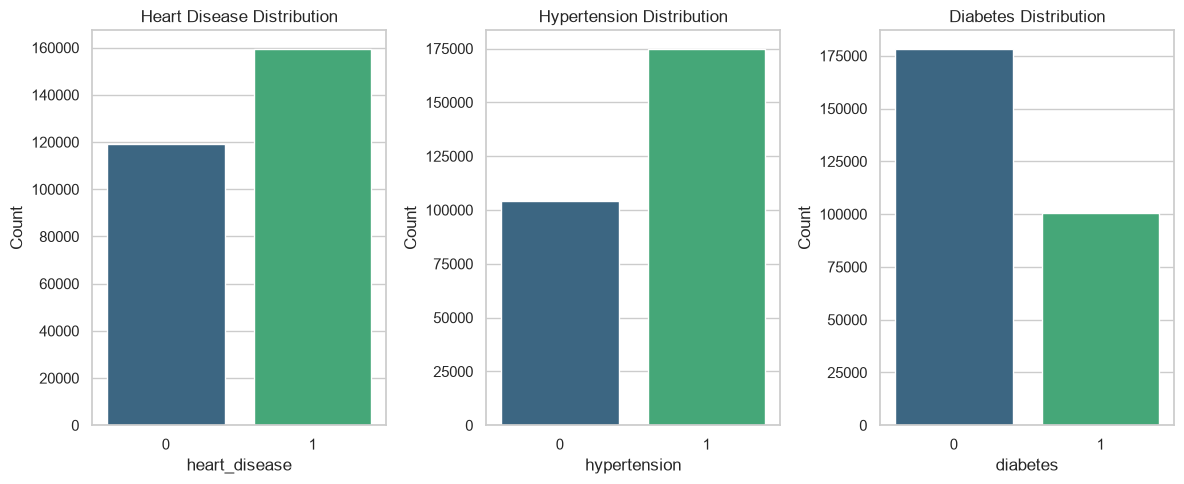

In [10]:
# We have 3 separate target columns
targets = ['heart_disease', 'hypertension', 'diabetes']

# Convert heart_disease and hypertension to binary (0/1) format like diabetes
df_cleaned['heart_disease'] = (df_cleaned['heart_disease'] > 0).astype(int)
df_cleaned['hypertension'] = (df_cleaned['hypertension'] > 0).astype(int)
df_cleaned['diabetes'] = (df_cleaned['diabetes'] == 'Yes').astype(int)

print("Targets converted to binary format:")
display(df_cleaned[targets].head(10))

plt.figure(figsize=(12, 5))
for i, target in enumerate(targets, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df_cleaned, x=target, palette='viridis')
    plt.title(f'{target.replace("_", " ").title()} Distribution')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Inference from Graph 1:** 
By visualizing our three distinct targets (`heart_disease`, `hypertension`, `diabetes`), we can assess the class balance for each specific disease. If any of these classes are heavily imbalanced (e.g., 90% zeros and 10% ones), the ML Engineer will need to apply balancing techniques (like SMOTE or class weighting) during Phase 2.

### Graph 2: Correlation Heatmap

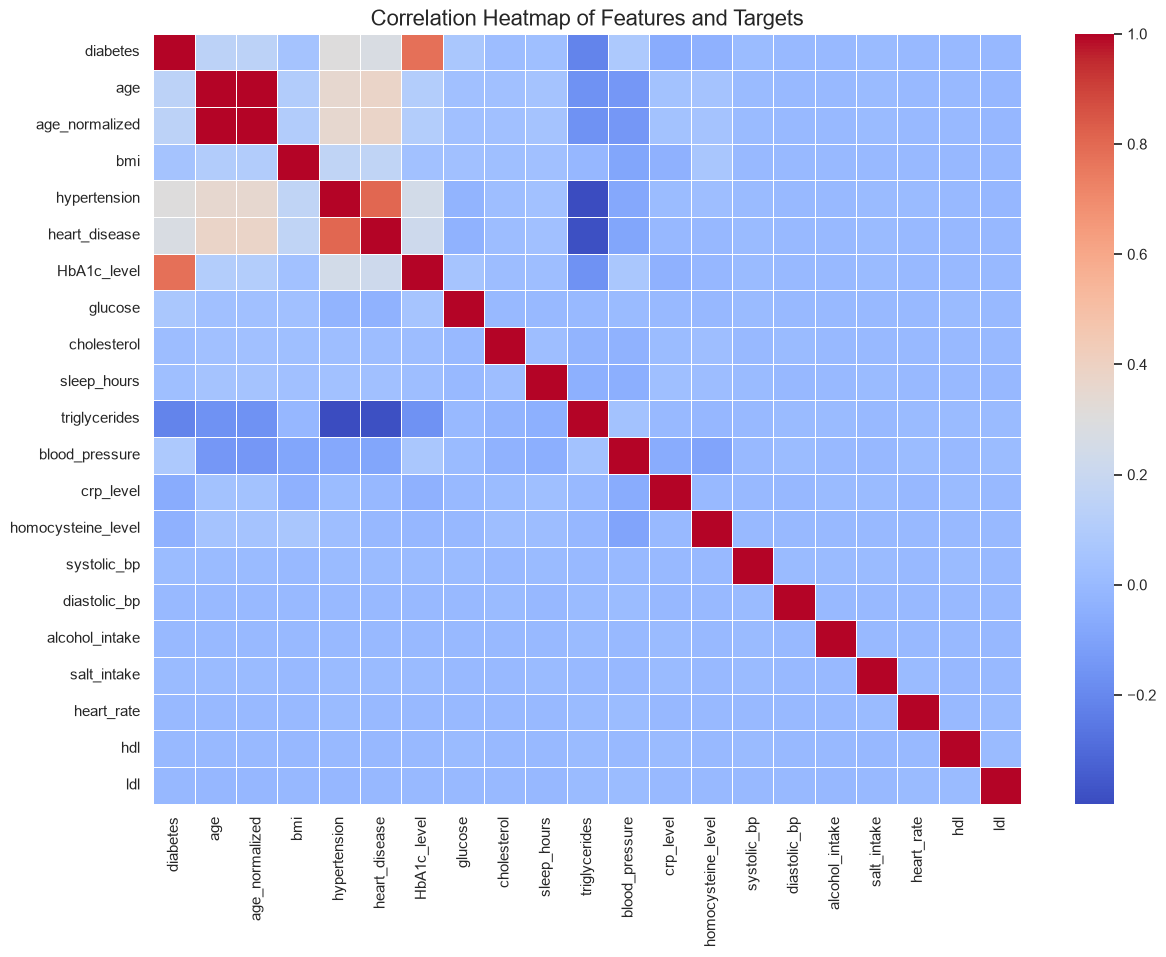

In [11]:
plt.figure(figsize=(14, 10))

# Calculate correlation matrix for numeric columns only
corr_matrix = df_cleaned.select_dtypes(include=[np.number]).corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features and Targets', fontsize=16)
plt.show()

**Inference from Correlation Heatmap:** 
This heatmap visualizes the linear relationships between all numerical features and our three target diseases. 
*   **Feature-Target Correlation:** Dark red or dark blue spots between a feature and a target indicate a strong positive or negative correlation, making that feature a strong predictor.
*   **Multicollinearity:** If two features are highly correlated with each other (e.g., above 0.8), we might consider dropping one of them later to simplify the model and avoid multicollinearity.

### Graph 3: Feature Distribution by Targets

We will dynamically pick the first two continuous numeric features to see how they relate to the diseases.

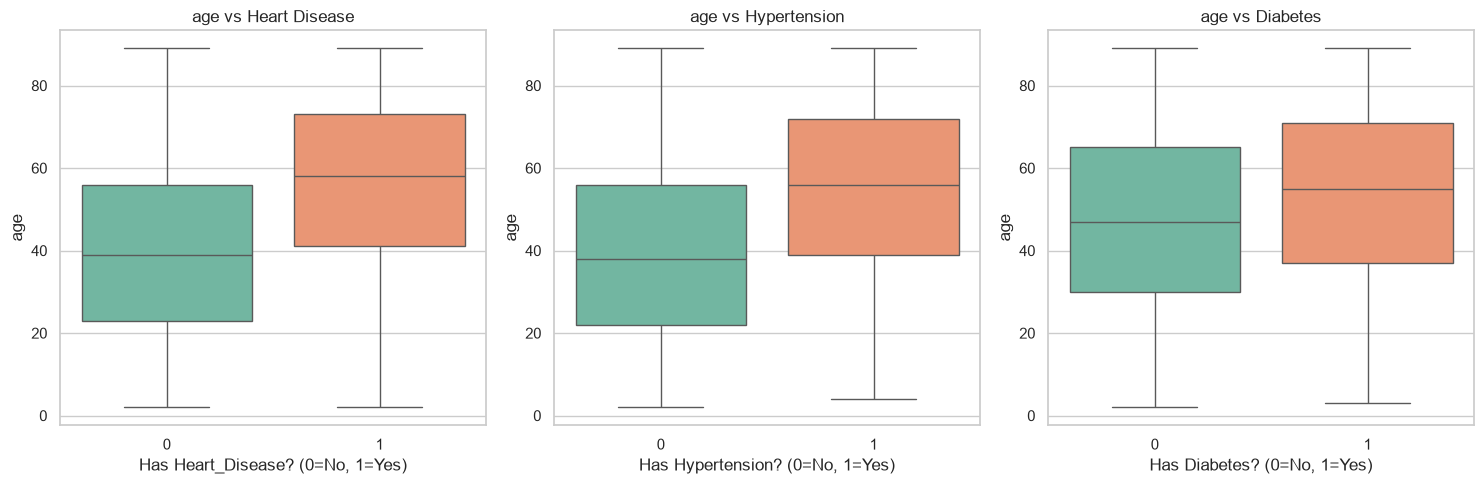

In [12]:
numeric_features = df_cleaned.select_dtypes(include=[np.number]).columns.drop(targets, errors='ignore')

if len(numeric_features) >= 2:
    feature_to_plot = numeric_features[0] # it can be changed to any other numeric feature you want to visualize against the targets
    
    plt.figure(figsize=(15, 5))
    for i, target in enumerate(targets, 1):
        plt.subplot(1, 3, i)
        sns.boxplot(data=df_cleaned, x=target, y=feature_to_plot, palette='Set2')
        plt.title(f'{feature_to_plot} vs {target.replace("_", " ").title()}')
        plt.xlabel(f'Has {target.title()}? (0=No, 1=Yes)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for boxplots.")

**Inference from Feature Distributions:** 
These boxplots illustrate how a specific continuous feature varies between patients who have the disease (1) and those who do not (0). 
*   If the boxes (median and interquartile ranges) are at significantly different levels on the Y-axis, it implies that this feature strongly influences whether a patient gets the disease or not. 
*   It also helps us spot potential **outliers** in the data that might need further cleaning.

### Graph 4: Skewness Check & Feature Transformation

Before feature selection, it is important to check the distribution of continuous numerical features. Highly skewed data (skewness > 1 or < -1) can degrade the performance of certain machine learning algorithms and typically requires mathematical transformations (e.g., Log1p or Box-Cox) to stabilize the variance. 

In a complex, real-time multi-model architecture, keeping the preprocessing pipeline lean is critical for maintaining low inference latency. We will calculate the skewness of our continuous features and visualize a few key distributions to determine if transformations are strictly necessary.

--- Feature Skewness Scores ---
blood_pressure        0.460528
glucose               0.381901
bmi                   0.306227
sleep_hours           0.044006
cholesterol           0.033675
systolic_bp           0.012621
salt_intake           0.008081
alcohol_intake       -0.000280
heart_rate           -0.001178
diastolic_bp         -0.002949
hdl                  -0.012423
ldl                  -0.023198
homocysteine_level   -0.037071
triglycerides        -0.056623
age                  -0.061136
HbA1c_level          -0.190506
crp_level            -0.277183
dtype: float64

Conclusion: All continuous features have a skewness score between -0.5 and 0.5.
The data is highly symmetrical. No mathematical transformations (like Log1p) are required.


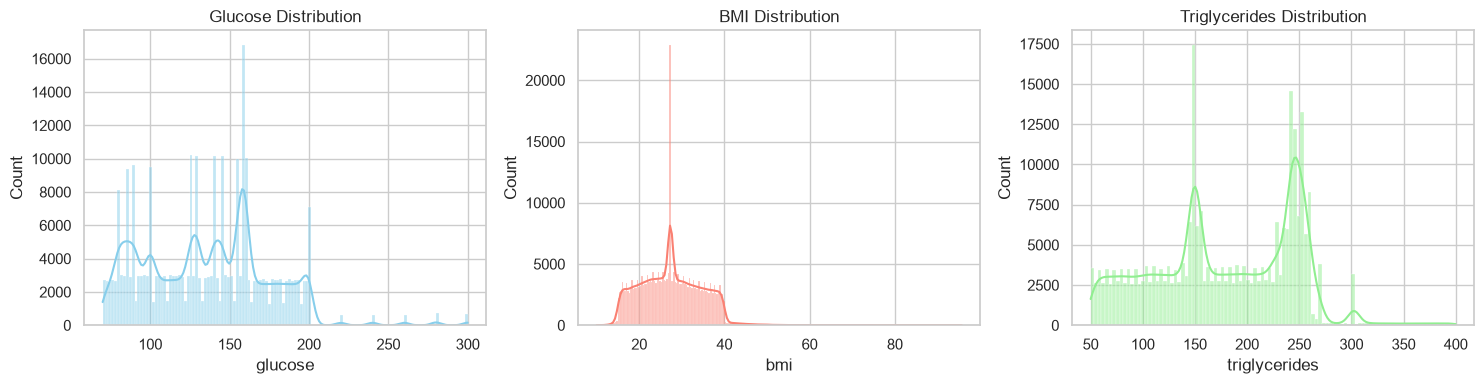

In [13]:
# Identify continuous columns
continuous_cols = [
    'age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 
    'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 
    'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 
    'heart_rate', 'hdl', 'ldl'
]

# Calculate skewness for continuous features
# Note: Skewness between -0.5 and 0.5 indicates a fairly symmetrical distribution.
skewness = df_cleaned[continuous_cols].skew().sort_values(ascending=False)

print("--- Feature Skewness Scores ---")
print(skewness)
print("\nConclusion: All continuous features have a skewness score between -0.5 and 0.5.")
print("The data is highly symmetrical. No mathematical transformations (like Log1p) are required.")

# Visualize a few key distributions to confirm visually
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_cleaned['glucose'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Glucose Distribution')

sns.histplot(df_cleaned['bmi'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('BMI Distribution')

sns.histplot(df_cleaned['triglycerides'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Triglycerides Distribution')

plt.tight_layout()
plt.show()

## 4. Feature Selection & Multicollinearity Handling

In this step, we will drop redundant features that represent the same underlying data to prevent multicollinearity (which can confuse the model and artificially inflate feature importance).

In [14]:
# List of redundant columns to drop based on correlation insights
redundant_columns = [
    'age_normalized',       # Redundant with 'age'
    'age_level',            # Redundant with 'age'
    'bmi_level',            # Redundant with 'bmi'
    'blood_pressure',       # Redundant with 'systolic_bp' and 'diastolic_bp'
    'high_blood_pressure'   # Redundant with the continuous bp features
]

# Drop the columns
df_cleaned = df_cleaned.drop(columns=[col for col in redundant_columns if col in df_cleaned.columns])

print(f"Shape after removing redundant features: {df_cleaned.shape}")

Shape after removing redundant features: (278701, 29)


## 5. Categorical Variable Encoding
Machine learning models require numerical inputs. We will encode our string variables using three methods:
1. **Binary Encoding:** For Yes/No or Male/Female features.
2. **Ordinal Encoding:** For categorical variables that have a natural ranking (e.g., Low, Moderate, High).
3. **One-Hot Encoding:** For nominal variables without an inherent ranking (e.g., employment status).

In [15]:
# 1. Binary Encoding
binary_mapping = {'Yes': 1, 'No': 0}
binary_cols = ['family_history', 'low_hdl_cholesterol', 'high_ldl_cholesterol']

for col in binary_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].map(binary_mapping)

if 'gender' in df_cleaned.columns:
    df_cleaned['gender'] = df_cleaned['gender'].map({'Male': 1, 'Female': 0})

# 2. Ordinal Encoding
# Mapping for Low/Moderate/High
ordinal_mapping = {'Low': 0, 'Moderate': 1, 'Medium': 1, 'High': 2} 
ordinal_cols = ['physical_activity', 'stress_level', 'sugar_consumption']

for col in ordinal_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].map(ordinal_mapping)

# Mapping for Education Level
if 'education_level' in df_cleaned.columns:
    edu_mapping = {'Primary': 0, 'Secondary': 1, 'Tertiary': 2}
    df_cleaned['education_level'] = df_cleaned['education_level'].map(edu_mapping)

# 3. One-Hot Encoding for remaining nominal categorical variables
# Using drop_first=True to avoid the dummy variable trap
nominal_cols = ['smoking', 'employment_status']
df_cleaned = pd.get_dummies(df_cleaned, columns=[col for col in nominal_cols if col in df_cleaned.columns], drop_first=True, dtype=int)

print(f"Shape after all encoding: {df_cleaned.shape}")

# Verify that all columns are now numeric
print("\\nData Types after Encoding:")
display(df_cleaned.dtypes.value_counts())
display(df_cleaned.head())

Shape after all encoding: (278701, 31)
\nData Types after Encoding:


int64      16
float64    15
Name: count, dtype: int64

,gender,diabetes,age,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,...,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,smoking_Former,smoking_Never,employment_status_Retired,employment_status_Unemployed
0,0,0,9,19.20,0,0,5.8,158.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
1,0,0,3,22.55,0,0,6.6,159.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
2,0,0,3,22.89,0,0,4.0,126.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
3,0,0,3,23.12,0,0,6.2,85.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
4,0,0,4,19.61,0,0,5.7,155.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0


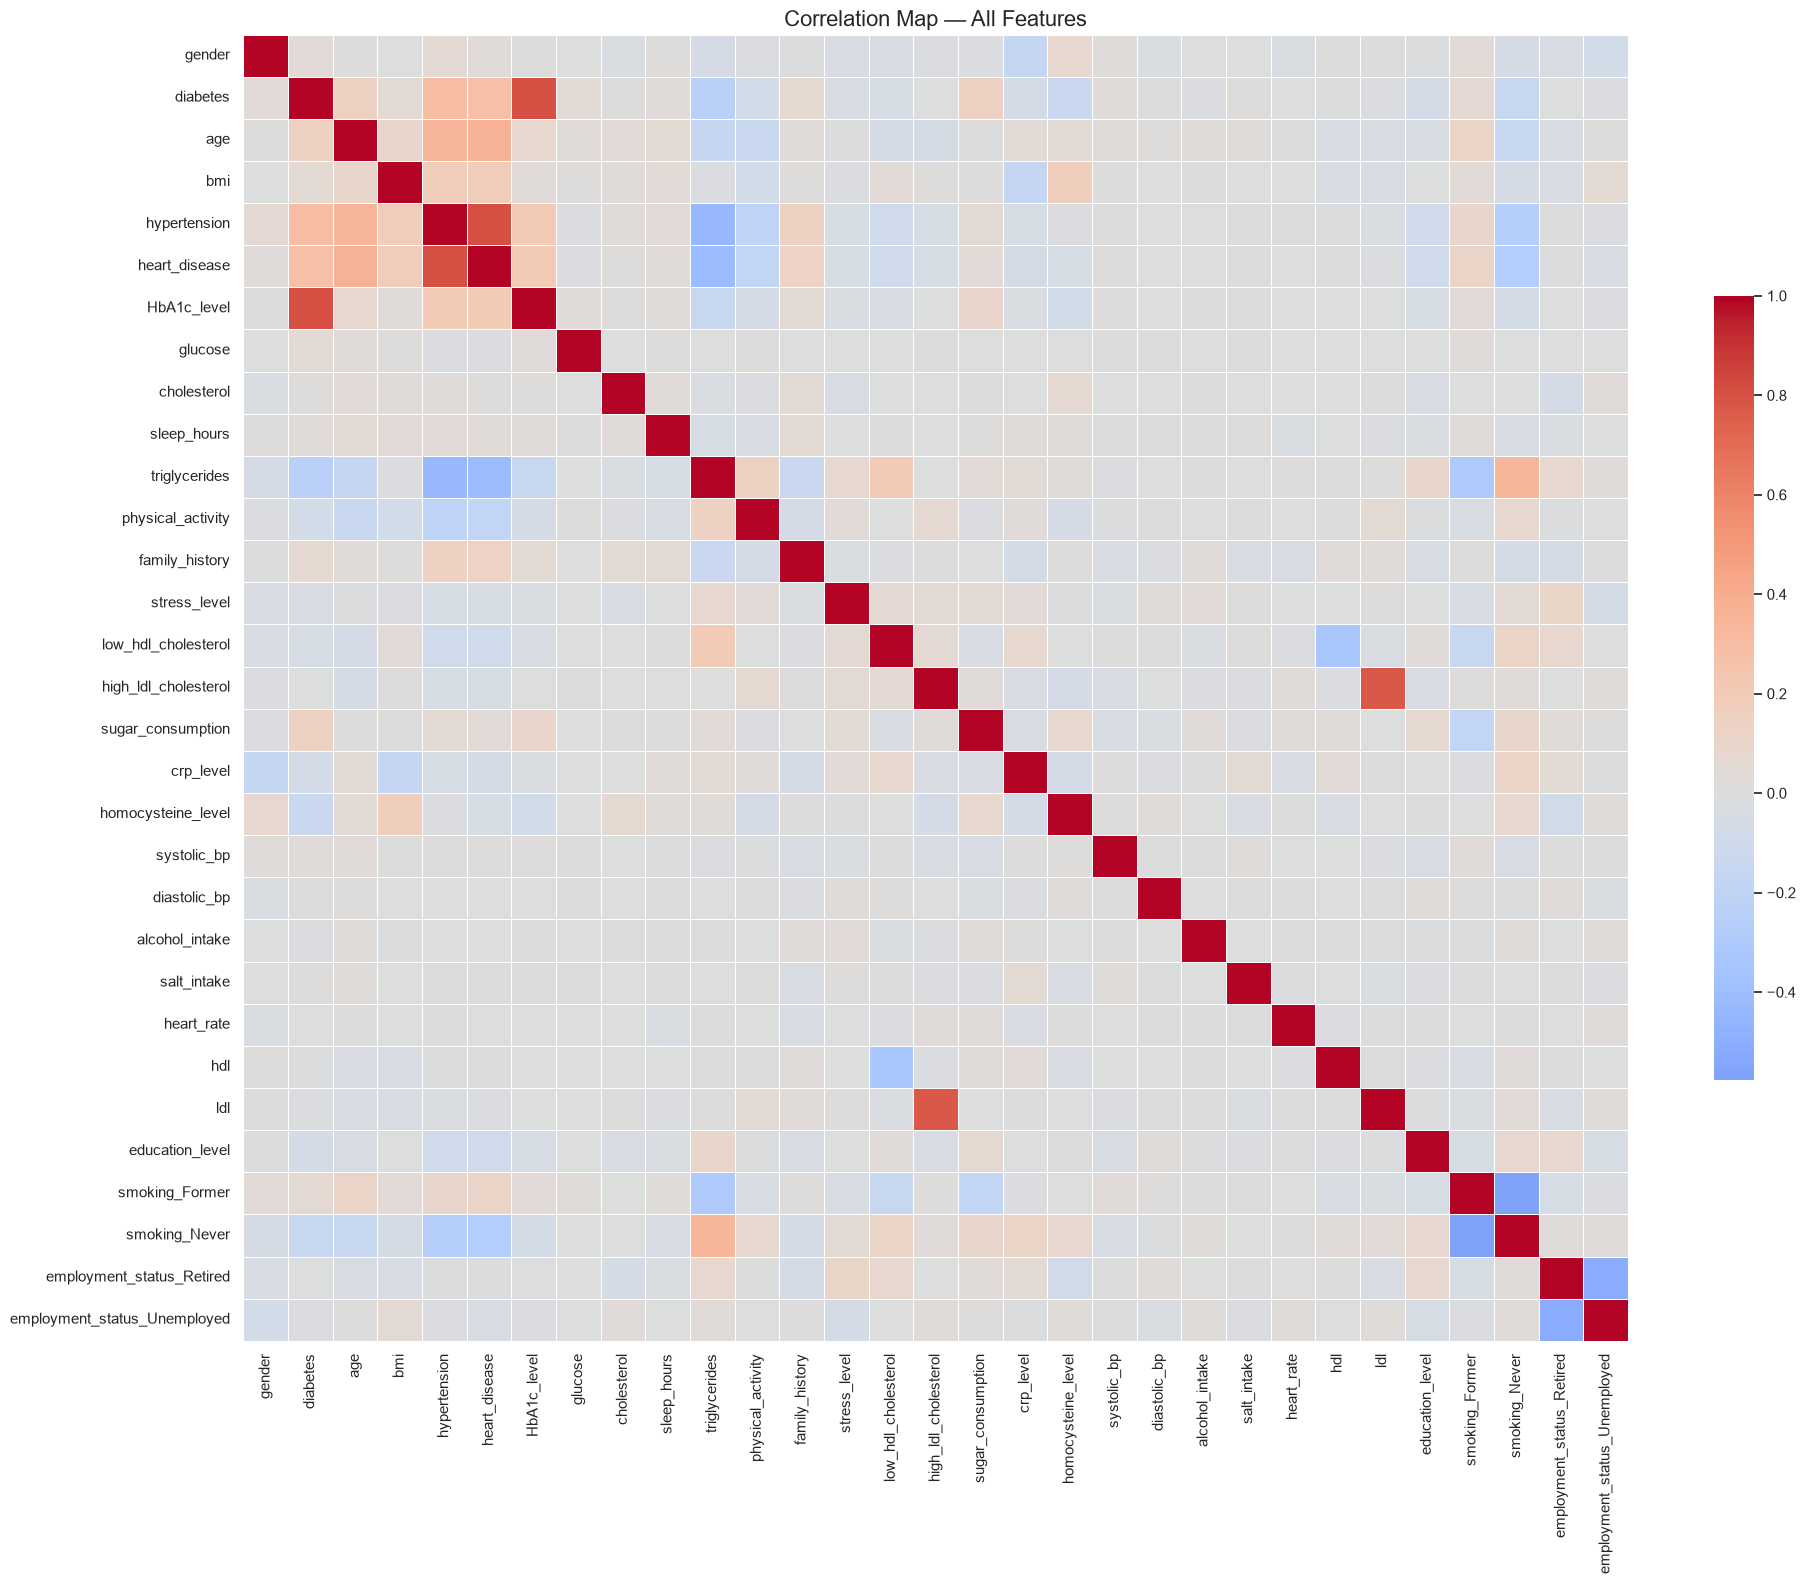

In [16]:
# Correlation map between all features (convert non-numeric to categorical codes first)
corr_df = df_cleaned.copy()

for col in corr_df.columns:
    if not np.issubdtype(corr_df[col].dtype, np.number):
        corr_df[col] = pd.Categorical(corr_df[col]).codes

corr_all = corr_df.corr(method='spearman')

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_all, dtype=bool))
sns.heatmap(corr_all,  cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink':0.6})
plt.title('Correlation Map — All Features', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Save the Preprocessed Dataset

In [17]:
df_cleaned.to_csv('leakage_free_chronic_dataset.csv', index=False)
display(df_cleaned.head())
print(f"Cleaned Shape: {df_cleaned.shape}")
print("✅ Data sanitized, leakage resolved, and saved successfully as 'leakage_free_chronic_dataset.csv'")

,gender,diabetes,age,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,...,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,smoking_Former,smoking_Never,employment_status_Retired,employment_status_Unemployed
0,0,0,9,19.20,0,0,5.8,158.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
1,0,0,3,22.55,0,0,6.6,159.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
2,0,0,3,22.89,0,0,4.0,126.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
3,0,0,3,23.12,0,0,6.2,85.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0
4,0,0,4,19.61,0,0,5.7,155.0,214.703704,6.864403,...,14.777636,8.685304,74.329073,65.651757,129.220447,0,0,1,1,0


Cleaned Shape: (278701, 31)
✅ Data sanitized, leakage resolved, and saved successfully as 'leakage_free_chronic_dataset.csv'


---
# Phase 2: Machine Learning Modeling
**Responsible:** Marwan Ayman

In this phase, we will separate our features from our targets, split the data into training and testing sets, and train a Multi-Output Random Forest Classifier to predict all three medical conditions simultaneously.

## 1. Hyperparameter Tuning
To squeeze the highest possible accuracy and recall out of our model, we will use `GridSearchCV` to find the optimal hyperparameters. 

Since our `RandomForestClassifier` is wrapped inside a `MultiOutputClassifier`, we must use the `estimator__` prefix for our parameter grid keys so the grid search knows to apply them to the underlying Random Forest.

In [21]:
from sklearn.multioutput import MultiOutputClassifier

# 1. Define Features (X) and Targets (y)
targets = ['heart_disease', 'hypertension', 'diabetes']
X = df_cleaned.drop(columns=targets)
y = df_cleaned[targets]

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the base model and multi-output wrapper
base_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
multi_target_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

# 4. Define the Parameter Grid
param_grid = {
    'estimator__n_estimators': [100, 150],
    'estimator__max_depth': [10, 15, 20],
    'estimator__min_samples_split': [2, 5]
}

# 5. Initialize GridSearchCV
# We use scoring='f1_macro' to prioritize balancing precision and recall due to class imbalance
grid_search = GridSearchCV(
    estimator=multi_target_rf,
    param_grid=param_grid,
    cv=3, 
    n_jobs=-1,
    verbose=2,
    scoring='f1_macro' 
)

print("Starting Grid Search... (This may take some time depending on your hardware)")
grid_search.fit(X_train, y_train)

print(f"\\nBest Parameters Found: {grid_search.best_params_}")

Starting Grid Search... (This may take some time depending on your hardware)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
\nBest Parameters Found: {'estimator__max_depth': 20, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 150}


## 2. Optimized Model Evaluation
Now that we have found the optimal hyperparameters, we will extract the best estimator from our grid search and evaluate its performance on the unseen test data.

In [22]:
# Extract the best model from the grid search
best_multi_target_rf = grid_search.best_estimator_

# Generate predictions
y_pred_best = best_multi_target_rf.predict(X_test)

# Evaluate each target separately
for i, target in enumerate(targets):
    print(f"\\n{'='*40}")
    print(f"Optimized Classification Report: {target.replace('_', ' ').title()}")
    print(f"{'='*40}")
    print(classification_report(y_test.iloc[:, i], y_pred_best[:, i]))

\n========================================
Optimized Classification Report: Heart Disease
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     23803
           1       1.00      0.98      0.99     31938

    accuracy                           0.99     55741
   macro avg       0.98      0.99      0.99     55741
weighted avg       0.99      0.99      0.99     55741

\n========================================
Optimized Classification Report: Hypertension
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     20834
           1       1.00      0.96      0.98     34907

    accuracy                           0.97     55741
   macro avg       0.97      0.98      0.97     55741
weighted avg       0.98      0.97      0.98     55741

\n========================================
Optimized Classification Report: Diabetes
              precision    recall  f1-score   support

           0       1.00    

## 3. Export the Optimized Model for Deployment
**Responsible:** Hassan Raafat

We will save the optimized multi-output model to disk so it can be loaded into our local web server using Streamlit.

In [23]:
# Save the trained model to a file
model_filename = 'optimized_multi_target_medical_model.pkl'
joblib.dump(best_multi_target_rf, model_filename)

print(f"✅ Optimized model saved successfully as '{model_filename}'")

✅ Optimized model saved successfully as 'optimized_multi_target_medical_model.pkl'
